### 工作進度  
* 新的筆記架構仍待定。初步構想於下：  
  - 第一部分：大盤解盤  
    * 『加權指數』與『櫃買指數』  
      - 補充老師盤中資訊，並將K線圖與畫線進行「量化」。  
      - 對照老師的「盤前快訊」。  
  - 第二部分：個股解盤  
    * **選股**  
      - 老師觀察股 ： 將K線圖與畫線進行「量化」。  
      - 自選觀察股  
    * 補充籌碼面資訊  

#### 引入模組與定義公用函式  
* 模組化？ 一般化？

In [1]:
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
import datetime
import sqlite3

from talib.abstract import *

In [3]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

In [4]:
def k_line_chart_visualization(stock_id , range_start_date, range_end_date, callback_function) :
    # 設定價格資料之日期範圍
    current_date       = datetime.datetime.today()
    daily_end_date     = current_date.strftime('%Y-%m-%d')
    daily_start_date,_ = mysys.get_monday_to_sunday((current_date - datetime.timedelta(days=730)).strftime('%Y-%m-%d'))

    # 連線資料庫
    conn = sqlite3.connect('data/stock.db')

    # 從資料庫中載入「台股總覽 TaiwanStockInfo」
    df_stock_info = pd.read_sql("SELECT * FROM StockInfo", conn)

    # 將載入的「台股總覽 TaiwanStockInfo」進行格式轉換
    df_stock_info.set_index(df_stock_info['StockID'],inplace=True)
    df_stock_info = df_stock_info.drop(columns=['StockID'])
    
    # 取得該股票代碼的產業分類
    industry_category = df_stock_info.loc[stock_id]['IndustryCategory']
    
    # 讀取日Ｋ價格資料
    sql_cmd = "SELECT * FROM DailyPrice WHERE StockID='{}' AND (Date BETWEEN '{}' AND '{}')".format(stock_id,daily_start_date,daily_end_date)
    daily_price_df = pd.read_sql( sql_cmd, conn)
    
    # 格式轉換：日期格式、成交量(成交值)
    daily_price_df           = daily_price_df.drop(columns=['SerialNo','StockID'])
    daily_price_df['Date']   = daily_price_df['Date'].astype('datetime64[ns]')
    daily_price_df.set_index(daily_price_df['Date'],inplace=True)
    daily_price_df.drop(columns=['Date'],inplace=True)
    if industry_category == 'Index' or industry_category == '大盤' :
        daily_price_df           = daily_price_df.drop(columns=['Volume'])
        daily_price_df           = daily_price_df.rename(columns={'Value':'Volume'})
        daily_price_df['Volume'] = daily_price_df['Volume'].div(100000000.00)
        daily_price_df['Volume'] = daily_price_df['Volume'].round(2)
    else :
        daily_price_df           = daily_price_df.drop(columns=['Value'])
        daily_price_df['Volume'] = daily_price_df['Volume'].div(1000)
        daily_price_df['Volume'] = daily_price_df['Volume'].round()
        daily_price_df['Volume'] = daily_price_df['Volume'].astype('int64')

    # 關閉資料庫
    conn.close()
    
    # 確認範圍的開始與結束日期存在於價格資料中
    if range_start_date not in daily_price_df.index or range_end_date not in daily_price_df.index :
        print(range_start_date,range_end_date,daily_price_df.index)
        return None
        
    # 日Ｋ價格資料轉換為talib格式
    daily_price_df_talib          = daily_price_df.copy()
    daily_price_df_talib.columns  = [ i.lower() for i in daily_price_df_talib.columns]
            
    # 計算移動平均線
    talib_sma5        = SMA( daily_price_df_talib, timeperiod=5)
    talib_sma10       = SMA( daily_price_df_talib, timeperiod=10)
    talib_sma20       = SMA( daily_price_df_talib, timeperiod=20)
    talib_sma60       = SMA( daily_price_df_talib, timeperiod=60)
    talib_sma120      = SMA( daily_price_df_talib, timeperiod=120)
    talib_sma240      = SMA( daily_price_df_talib, timeperiod=240)
    # 設定名稱
    talib_sma5.name   = 'SMA5'
    talib_sma10.name  = 'SMA10'
    talib_sma20.name  = 'SMA20'
    talib_sma60.name  = 'SMA60'
    talib_sma120.name = 'SMA120'
    talib_sma240.name = 'SMA240'
    # 合併各條均線
    talib_sma_df      = pd.concat([talib_sma5, talib_sma10, talib_sma20, talib_sma60, talib_sma120, talib_sma240], axis=1)
    # 取小數點後兩位
    sma_df            = talib_sma_df.round(2)
    
    # 設定價格範圍
    range_prices = daily_price_df[range_start_date:range_end_date]
    # 設定均線範圍
    range_sma    = sma_df[range_start_date:range_end_date]
    
    # 呼叫回呼函式
    seq_of_seq_of_points, linewidths, colors = callback_function(range_prices)
    
    # 設定K線格式
    mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
    s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
    
    # 設定均線
    added_plots = [
        mpf.make_addplot(range_sma['SMA5'],width=0.8,color='xkcd:red brown'),
        mpf.make_addplot(range_sma['SMA10'],width=0.8,color='xkcd:dark sky blue'),
        mpf.make_addplot(range_sma['SMA20'],width=1.0,color='xkcd:violet'),
        mpf.make_addplot(range_sma['SMA60'],width=0.8,color='xkcd:orange')
    ]

    # 繪製K線圖
    kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=added_plots, alines=dict(alines=seq_of_seq_of_points, linewidths=tuple(linewidths), colors=tuple(colors), alpha=0.6), volume=True, datetime_format='%Y-%m-%d')
    mpf.plot(range_prices,**kwargs)

#### 建立「解盤」物件    

In [5]:
analysis = mysys.StockAnalysis()

### 指數解盤  

* 加權指數

解盤內容：


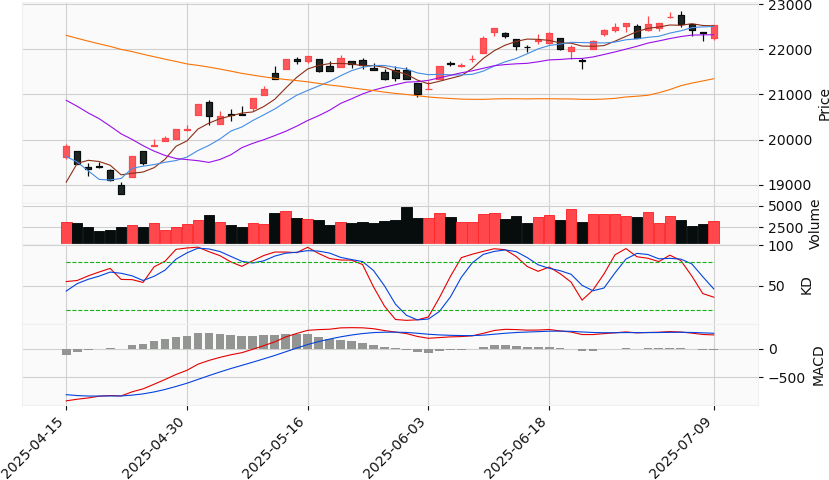

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"紡錘線 : 2025-07-03 十字線 : 2025-07-03 , 2025-07-08 吞噬 : 2025-07-04 , 2025-07-09"
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 3225.28億元 ，十日均量 ＝ 3456.28億元）
型態,反轉型態之三重頂，型態範圍由2024-08-12開始到2025-03-03結束，估算目標價為21371.25。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為22257.56。
移動平均線,5日線下彎、10日線上揚，短期盤整；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-04死亡交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。並且2025-06-30該周在超買區。
整體評價,"價格趨勢 目前價格處於盤整階段。近期價格在高位出現震盪，K線圖顯示多空雙方力量相對均衡。 價量關係 成交量在近期有所減少，顯示市場交投熱情減弱。價格在高位盤整時，成交量未能有效放大，顯示多頭動能不足。 支撐與壓力 - 支撐位置：短期支撐位於20日移動平均線（紫色線）附近，約在22,000點。 - 壓力位置：上方壓力位於近期高點23,000點附近。 KD指標解讀 KD指標顯示K線和D線均從超買區回落，並且K線已經跌破D線，顯示短期內有進一步回檔的風險。 MACD指標解讀 MACD指標中，DIF線和MACD線接近零軸，且灰色柱體縮短，顯示多頭動能減弱，市場可能進入盤整或回檔階段。 綜合評價 目前市場處於高位盤整階段，短期內可能面臨回檔壓力。建議投資者謹慎操作，若價格跌破支撐位，需考慮停損。若價格能夠有效突破壓力位，則可考慮加碼進場。"


In [6]:
stock_analysis(analysis,'TAIEX')

加權指數小跌破20日線，20日線下彎：  
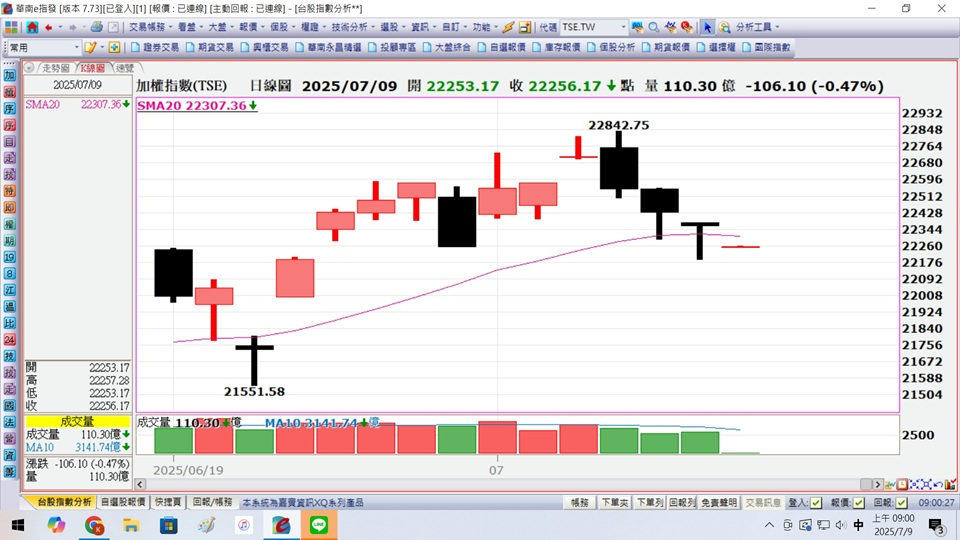  
小跌破上升楔形：  
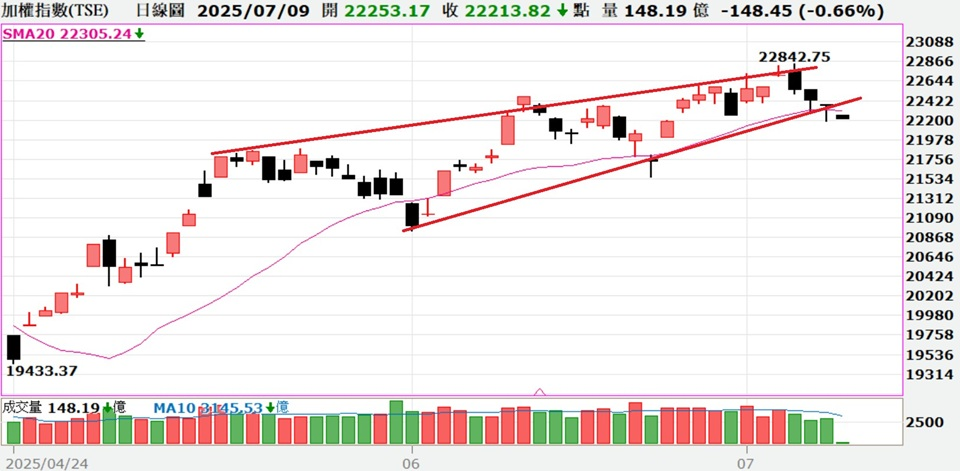  

看的出來很認真的防守關鍵支撐：  
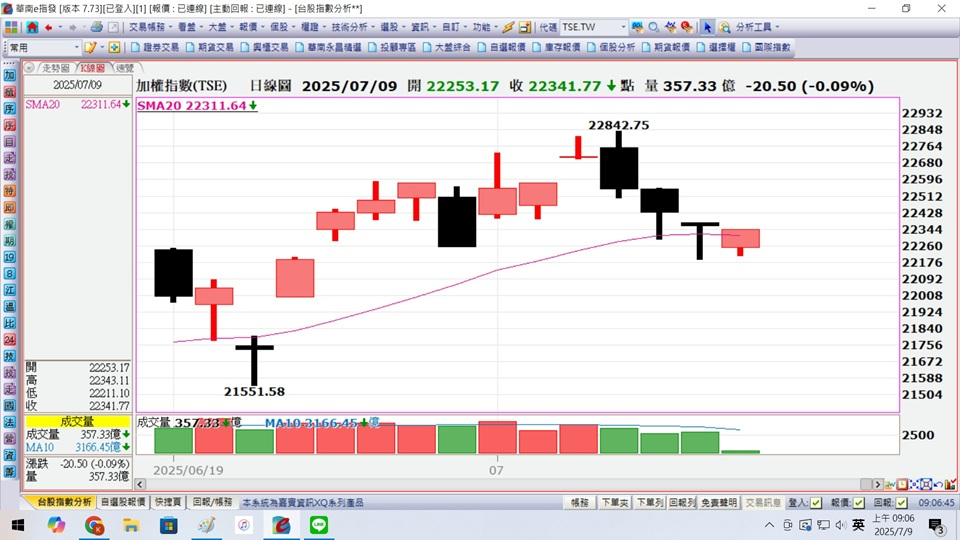  

In [7]:
def line_drawing_callback( range_prices) :
    # 設定楔形壓力線
    resistance_line_start_date  = '2025-05-13'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_x           = [mysys.date_to_index(range_prices,'2025-06-10'),mysys.date_to_index(range_prices,'2025-06-26')]
    resistance_line_y           = [range_prices.loc['2025-06-10']['High'],range_prices.loc['2025-06-26']['High']]
    slope,intercept             = np.polyfit(resistance_line_x,resistance_line_y,1)
    resistance_line_start_price = slope * mysys.date_to_index(range_prices,resistance_line_start_date) + intercept
    resistance_line_end_price   = slope * mysys.date_to_index(range_prices,resistance_line_end_date) + intercept

    # 設定楔形支撐線
    support_line_start_date  = '2025-05-29'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_x           = [mysys.date_to_index(range_prices,'2025-06-02'),mysys.date_to_index(range_prices,'2025-07-07')]
    support_line_y           = [(range_prices.loc['2025-06-02']['Close'] + range_prices.loc['2025-06-02']['Low'])/2,range_prices.loc['2025-07-07']['Low']]
    slope,intercept          = np.polyfit(support_line_x,support_line_y,1)
    support_line_start_price = slope * mysys.date_to_index(range_prices,support_line_start_date) + intercept
    support_line_end_price   = slope * mysys.date_to_index(range_prices,support_line_end_date) + intercept

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_start_price),(resistance_line_end_date,resistance_line_end_price)],
        [(support_line_start_date,support_line_start_price),(support_line_end_date,support_line_end_price)]
    ]

    linewidths=[1.5,1.5]
    
    colors=['xkcd:red','xkcd:red']

    return seq_of_seq_of_points,linewidths,colors

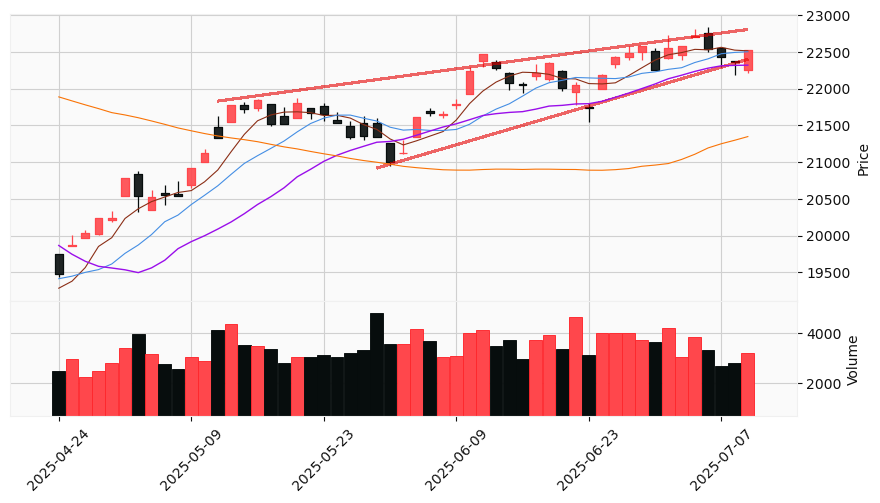

In [8]:
k_line_chart_visualization('TAIEX','2025-04-24','2025-07-09',line_drawing_callback)

* 櫃買指數

解盤內容：


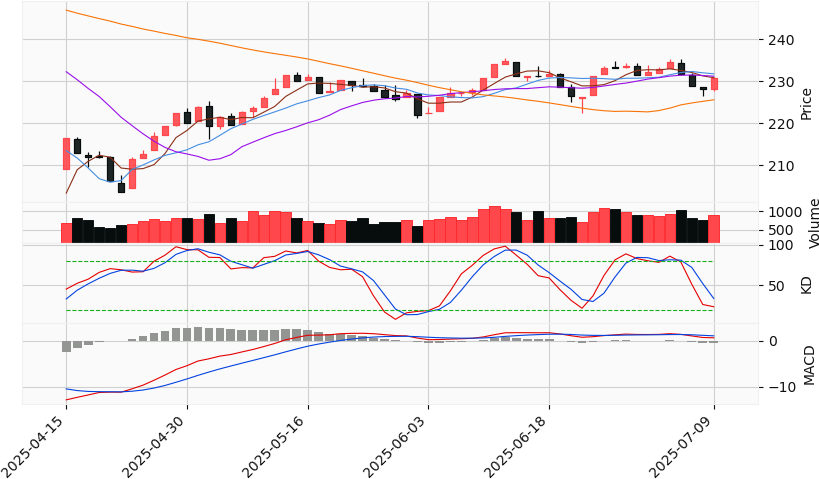

技術分析工具,解盤內容
Ｋ線／Ｋ棒,鎚子線／吊人線 : 2025-07-08 吞噬 : 2025-07-09
Ｋ線圖,中期為中位階 長期為低位階
成交量,價量關係：未至大量門檻（成交量 ＝ 903.03億元 ，十日均量 ＝ 915.7億元）
型態,盤整型態之三角形，型態範圍由2024-07-11開始到2025-03-28結束。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為247.79。
移動平均線,5日線下彎、10日線下彎，短期翻空；20日線下彎、60日線上揚，中期盤整；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-04死亡交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-02當周死亡交叉。
整體評價,價格趨勢 近期價格呈現盤整走勢。K線圖顯示價格在230點附近波動，短期移動平均線（5日、10日）與中期移動平均線（20日、60日）糾結，顯示市場缺乏明確方向。 價量關係 成交量在近期有所增加，但未能有效推動價格突破，顯示出多空雙方力量相對均衡，市場觀望情緒較重。 支撐與壓力 - 支撐位置：220點附近，為近期低點區域。 - 壓力位置：240點附近，為近期高點區域。 KD指標解讀 KD指標顯示K線與D線均從高位回落，並進入超賣區域，顯示短期內可能有反彈需求，但需觀察是否能有效突破D線。 MACD指標解讀 MACD指標中，DIF線與MACD線接近零軸，且OSC柱體由正轉負，顯示市場動能減弱，短期內可能持續盤整。 綜合評價 目前市場處於盤整階段，短期內缺乏明確方向。建議投資者謹慎觀望，等待市場出現明確的突破信號後再行操作。若價格突破240點壓力位，則可能進一步上行；若跌破220點支撐位，則需考慮停損。


In [9]:
stock_analysis(analysis,'TPEx')

櫃買指數相對穩定：  
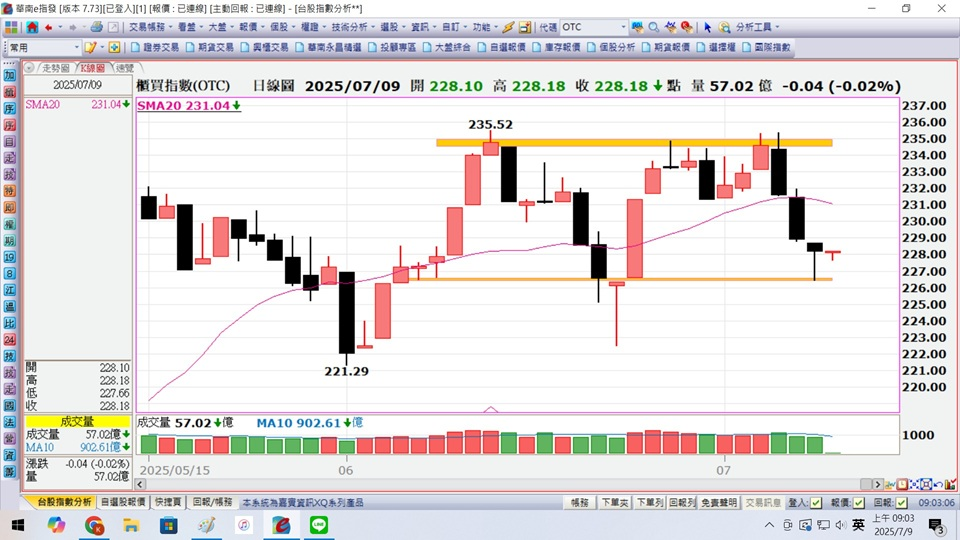  

In [10]:
def line_drawing_callback( range_prices) :
    # 設定箱型壓力線
    resistance_line_start_date  = '2025-06-09'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price       = range_prices.loc['2025-06-12']['Close']

    # 設定楔形支撐線
    support_line_start_date  = '2025-06-05'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_price       = range_prices.loc['2025-06-20']['Close']

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)],
        [(support_line_start_date,support_line_price),(support_line_end_date,support_line_price)]
    ]

    linewidths=[5.8,2.5]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

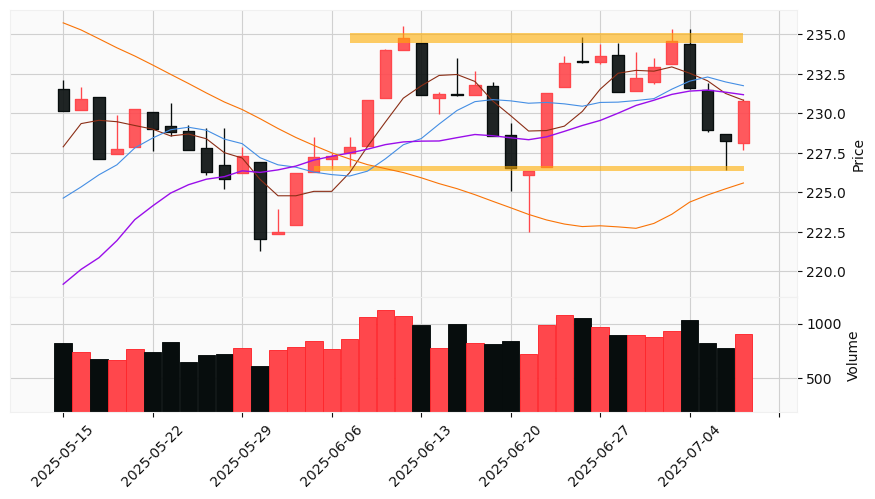

In [11]:
k_line_chart_visualization('TPEx','2025-05-15','2025-07-09',line_drawing_callback)